In [1]:
import pandas as pd
from os import getcwd
import seaborn as sns
import matplotlib.pyplot as plt
from pennylane.workflow.interfaces import torch
from torch._inductor.codegen.cuda.cutlass_lib_extensions.cutlass_mock_imports.cuda import cuda

import random_forest_model
from TODO.zadanie1.michal.graph_mtl_utils import MTLHybridNet

# print(getcwd())

df = pd.read_parquet('./../../../dataset.parquet')
tasks = ['cyp2c9_veith', 'cyp2d6_veith', 'cyp3a4_veith']
df = df[df['task'].isin(tasks)]

df_wide = df.pivot_table(index='smiles', columns='task', values='label')

In [2]:
print(df['task'].value_counts())
avg_tasks = df.groupby('smiles')['task'].nunique().mean()
print(f"Średnia liczba zadań na smiles: {avg_tasks:.2f}")
presence_mask = df_wide.notna().astype(int)

overlap_matrix = presence_mask.T @ presence_mask

stats_df = df.groupby('task')['label'].agg(['mean', 'count', 'std']).reset_index()
overlap_matrix = overlap_matrix.merge(stats_df, on='task')
overlap_matrix.head()

task
cyp2d6_veith    13130
cyp3a4_veith    12328
cyp2c9_veith    12092
Name: count, dtype: int64
Średnia liczba zadań na smiles: 2.33


,task,cyp2c9_veith,cyp2d6_veith,cyp3a4_veith,mean,count,std
0,cyp2c9_veith,12092,9750,9265,0.334519,12092,0.471841
1,cyp2d6_veith,9750,13130,9932,0.191470,13130,0.393473
2,cyp3a4_veith,9265,9932,12328,0.414504,12328,0.492656


### MTL model

In [3]:
%load_ext autoreload
%autoreload 2
from graph_mtl_utils import *
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
epochs = 20
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_tab, y, mask, tasks, splits, smiles_list = prepare_mtl_hybrid_data(df)

train_idx = splits == 'train'
val_idx = splits == 'valid'

train_loader = DataLoader(
    MTLHybridDataset(X_tab[train_idx], y[train_idx], mask[train_idx], [smiles_list[i] for i in np.where(train_idx)[0]]),
    batch_size=64, shuffle=True, collate_fn=collate_hybrid
)
val_loader = DataLoader(
    MTLHybridDataset(X_tab[val_idx], y[val_idx], mask[val_idx], [smiles_list[i] for i in np.where(val_idx)[0]]),
    batch_size=64, shuffle=False, collate_fn=collate_hybrid
)

model = MTLHybridNet(tab_dim=X_tab.shape[1], n_tasks=len(tasks), head_neurons=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

history = {
    'train_loss': [],
    'val_loss': [],
    'val_auc_avg': [],
    'val_aucs_per_task': {t: [] for t in tasks}
}

Rozpoczynam trening hybrydowego MTL (GNN + MLP) na 3 zadaniach...
Epoch 1/20 | Loss: 0.4502 | Val Loss: 0.3978 | Avg AUC: 0.8804
Epoch 2/20 | Loss: 0.3642 | Val Loss: 0.4007 | Avg AUC: 0.8900
Epoch 3/20 | Loss: 0.3196 | Val Loss: 0.3643 | Avg AUC: 0.8970
Epoch 4/20 | Loss: 0.2878 | Val Loss: 0.3922 | Avg AUC: 0.8900
Epoch 5/20 | Loss: 0.2604 | Val Loss: 0.3898 | Avg AUC: 0.8960
Epoch 6/20 | Loss: 0.2389 | Val Loss: 0.4320 | Avg AUC: 0.8844
Epoch 7/20 | Loss: 0.2199 | Val Loss: 0.4152 | Avg AUC: 0.8874
Epoch 8/20 | Loss: 0.2040 | Val Loss: 0.4315 | Avg AUC: 0.8852
Epoch 9/20 | Loss: 0.1867 | Val Loss: 0.4499 | Avg AUC: 0.8851
Epoch 10/20 | Loss: 0.1846 | Val Loss: 0.4593 | Avg AUC: 0.8884
Epoch 11/20 | Loss: 0.1755 | Val Loss: 0.4572 | Avg AUC: 0.8770
Epoch 12/20 | Loss: 0.1599 | Val Loss: 0.4796 | Avg AUC: 0.8814
Epoch 13/20 | Loss: 0.1482 | Val Loss: 0.4939 | Avg AUC: 0.8851
Epoch 14/20 | Loss: 0.1478 | Val Loss: 0.5237 | Avg AUC: 0.8879
Epoch 15/20 | Loss: 0.1391 | Val Loss: 0.4906 |

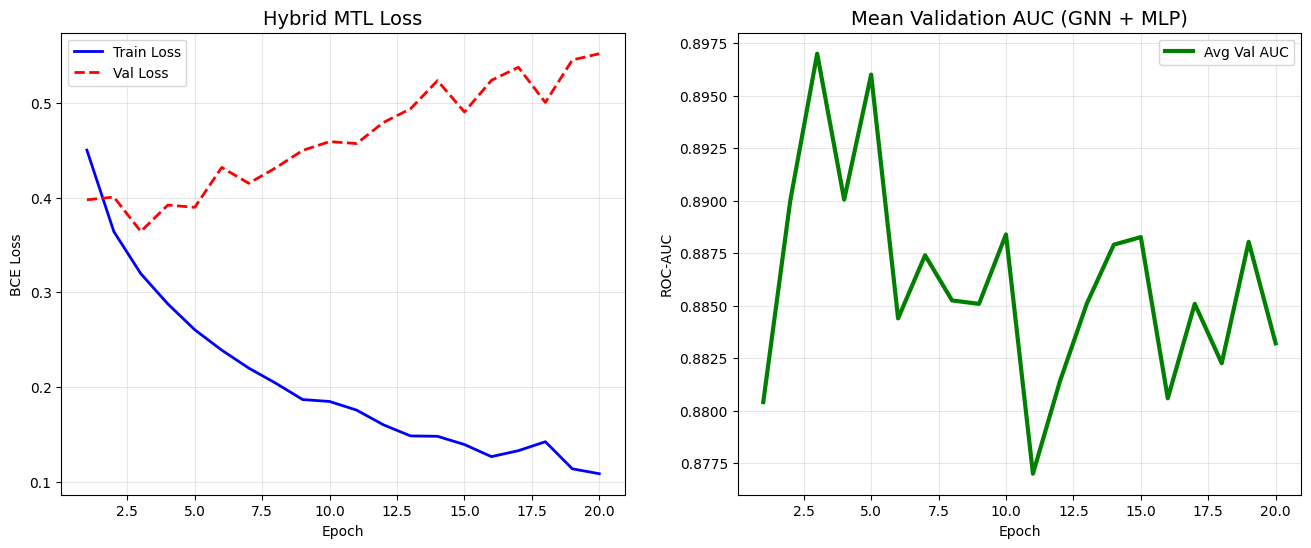

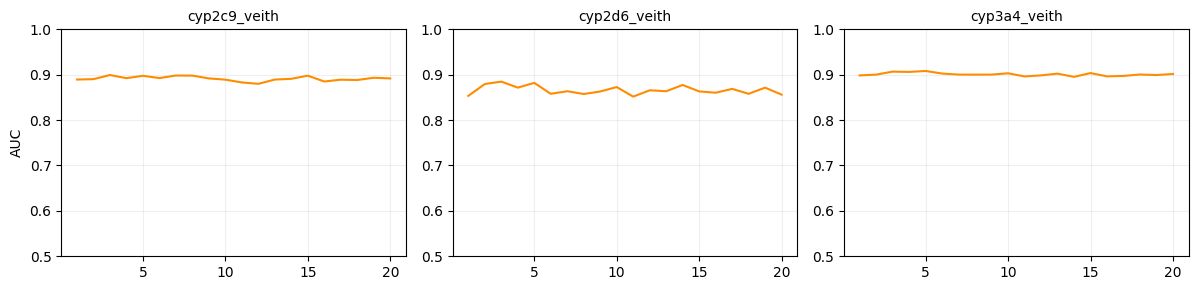

In [4]:
print(f"Rozpoczynam trening hybrydowego MTL (GNN + MLP) na {len(tasks)} zadaniach...")

for epoch in range(epochs):
    # TRENING
    model.train()
    epoch_train_loss = 0
    for batch_g, x_t, y_b, m_b in train_loader:
        batch_g, x_t, y_b, m_b = batch_g.to(device), x_t.to(device), y_b.to(device), m_b.to(device)

        optimizer.zero_grad()
        logits = model(batch_g, x_t)
        loss = F.binary_cross_entropy_with_logits(logits, y_b, reduction='none')
        loss = (loss * m_b).sum() / (m_b.sum() + 1e-8)

        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    # EVALUACJA
    model.eval()
    epoch_val_loss = 0
    all_preds, all_targets, all_masks = [], [], []

    with torch.no_grad():
        for batch_g, x_t, y_b, m_b in val_loader:
            batch_g, x_t, y_b, m_b = batch_g.to(device), x_t.to(device), y_b.to(device), m_b.to(device)
            logits = model(batch_g, x_t)

            v_loss = F.binary_cross_entropy_with_logits(logits, y_b, reduction='none')
            epoch_val_loss += ((v_loss * m_b).sum() / (m_b.sum() + 1e-8)).item()

            all_preds.append(torch.sigmoid(logits).cpu().numpy())
            all_targets.append(y_b.cpu().numpy())
            all_masks.append(m_b.cpu().numpy())

    # Obliczanie AUC per task
    preds = np.vstack(all_preds)
    targets = np.vstack(all_targets)
    masks = np.vstack(all_masks)

    current_aucs = {}
    for i, t in enumerate(tasks):
        m = masks[:, i] == 1
        if m.sum() > 0 and len(np.unique(targets[m, i])) > 1:
            auc = roc_auc_score(targets[m, i], preds[m, i])
        else:
            auc = np.nan
        current_aucs[t] = auc
        history['val_aucs_per_task'][t].append(auc)

    avg_auc = np.nanmean(list(current_aucs.values()))
    history['train_loss'].append(epoch_train_loss / len(train_loader))
    history['val_loss'].append(epoch_val_loss / len(val_loader))
    history['val_auc_avg'].append(avg_auc)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {history['train_loss'][-1]:.4f} | Val Loss: {history['val_loss'][-1]:.4f} | Avg AUC: {avg_auc:.4f}")
plot_hybrid_mtl_training(history, tasks)

## Porównanie wyników

In [6]:
history

{'train_loss': [0.45023572714315296,
  0.3641520444787828,
  0.3196483462375436,
  0.2877766038738402,
  0.2604129993814533,
  0.23887850428368412,
  0.21994014025407996,
  0.20398004374619427,
  0.1866712109264681,
  0.18462258244806765,
  0.1755025022700008,
  0.15991017390779183,
  0.14822490757468057,
  0.14782697214918622,
  0.13912129675769536,
  0.12634378265442148,
  0.1326177706363174,
  0.14208641604094183,
  0.11344353158005886,
  0.1082665229921287],
 'val_loss': [0.3978103112715941,
  0.40066159573885113,
  0.36431885911868167,
  0.39219994384508866,
  0.3898411808678737,
  0.43198511090416175,
  0.41521777327244097,
  0.43152174124350917,
  0.4499498402269987,
  0.4592804339929269,
  0.4572210197265332,
  0.47959208058623165,
  0.4939484652131796,
  0.523711146070407,
  0.4905693737360147,
  0.5240293311385008,
  0.5378373947281104,
  0.5006752239110378,
  0.5455992365112672,
  0.5521725996469076],
 'val_auc_avg': [np.float64(0.8804002920471988),
  np.float64(0.8899783568

In [8]:
import pandas as pd
import numpy as np
from SOTA_SCORES import SOTA_SCORES

df_rows_best = []

for task in tasks:
    row = {'Task': task}
    # Wyciągamy listy z historią AUC dla danego tasku i rozmiaru głowy
    gnn_vals = history['val_aucs_per_task'][task]

    # Używamy np.nanmax, żeby zignorować ewentualne wartości NaN,
    # zabezpieczając przed warningami, gdy cała tablica to NaNy
    row[f'GNN'] = np.nanmax(gnn_vals) if not np.isnan(gnn_vals).all() else np.nan

    # val = summary_df.loc[summary_df['task'] == task, 'auc']
    # row['Random_Forest'] = val.values[0] if not val.empty else np.nan
    row['SOTA'] = SOTA_SCORES[task]
    df_rows_best.append(row)

# Tworzymy DataFrame i ustawiamy Task jako indeks
df_best_val = pd.DataFrame(df_rows_best)
df_best_val.set_index('Task', inplace=True)

# Renderujemy tabelę formatując do 4 miejsc po przecinku
# i automatycznie podświetlamy maksymalną wartość w każdym wierszu (axis=1)
display(
    df_best_val.style
    .format("{:.4f}")
    .highlight_max(axis=1, color='green')
)

,GNN,SOTA
Task,,
cyp2c9_veith,0.8993,0.8590
cyp2d6_veith,0.8848,0.7900
cyp3a4_veith,0.9083,0.9160


In [9]:
# Generujesz kod HTML ze stylu
html_output = df_best_val.style.format("{:.4f}").highlight_max(axis=1, color='green').to_html()

# Zapisujesz do pliku
with open("./gnn_vs_SOTA.html", "w") as f:
    f.write(html_output)